In [4]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from collections import defaultdict
import random

In [5]:
def load_data(filename):
    graph = nx.Graph()
    added_edges = set()

    with open(filename, "r") as file:
        for line in file:
            if line.startswith("#"):
                continue
            node1, node2 = map(int, line.strip().split())

            edge = tuple(sorted((node1, node2)))
            if edge not in added_edges:
                graph.add_edge(*edge)
                added_edges.add(edge)

    return graph

In [6]:
filename = "ca-GrQc.txt"
G = load_data(filename)

In [7]:
def compute_knn_vs_k_real_graph(G):
    k_vs_knn = defaultdict(list)

    for node in G.nodes():
        k = len(list(G.neighbors(node)))
        if k == 0:
            continue
        neighbor_degrees = [G.degree(neigh) for neigh in G.neighbors(node)]
        knn = sum(neighbor_degrees) / k
        k_vs_knn[k].append(knn)

    k_vals = []
    knn_means = []

    for k in sorted(k_vs_knn.keys()):
        k_vals.append(k)
        knn_means.append(np.mean(k_vs_knn[k]))

    return k_vals, knn_means

In [8]:
real_k, real_knn = compute_knn_vs_k_real_graph(G)

In [9]:
def compute_average_knn_vs_k_random_graph(G, num_instances):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    p = (2 * m) / (n * (n - 1))

    knn_stats = defaultdict(list)

    for _ in range(num_instances):
        random_graph = nx.erdos_renyi_graph(n, p, seed=random.randint(0, 1e6))

        k_vs_knn = defaultdict(list)
        for node in random_graph.nodes():
            k = len(list(random_graph.neighbors(node)))
            if k == 0:
                continue
            neighbor_degrees = [random_graph.degree(neigh) for neigh in random_graph.neighbors(node)]
            knn = sum(neighbor_degrees) / k
            k_vs_knn[k].append(knn)

        for k in k_vs_knn:
            knn_stats[k].append(np.mean(k_vs_knn[k]))

    avg_k = sorted(knn_stats.keys())
    avg_knn = [np.mean(knn_stats[k]) for k in avg_k]
    std_knn = [np.std(knn_stats[k]) for k in avg_k]

    return avg_k, avg_knn, std_knn

In [10]:
rand_k, rand_knn, rand_std = compute_average_knn_vs_k_random_graph(G, 100)

In [11]:
def plot_degree_correlation_comparison(real_k, real_knn, rand_k, rand_knn, rand_std, output_file):
    plt.figure(figsize=(8, 6))
    plt.xscale("log")
    plt.yscale("log")

    plt.plot(real_k, real_knn, 'o-', label="Real-world network", color='blue')
    plt.errorbar(rand_k, rand_knn, yerr=rand_std, fmt='s--', color='red',
                 ecolor='gray', elinewidth=1, capsize=3, label="Random network avg ± std")

    plt.xlabel("Node degree $k$")
    plt.ylabel("Average neighbor degree $k_{nn}(k)$")
    plt.title("Degree Correlation (log-log): $k_{nn}(k)$ vs $k$")
    plt.legend()
    plt.grid(True, which="both", ls="--", lw=0.5)
    plt.tight_layout()
    plt.savefig(output_file)

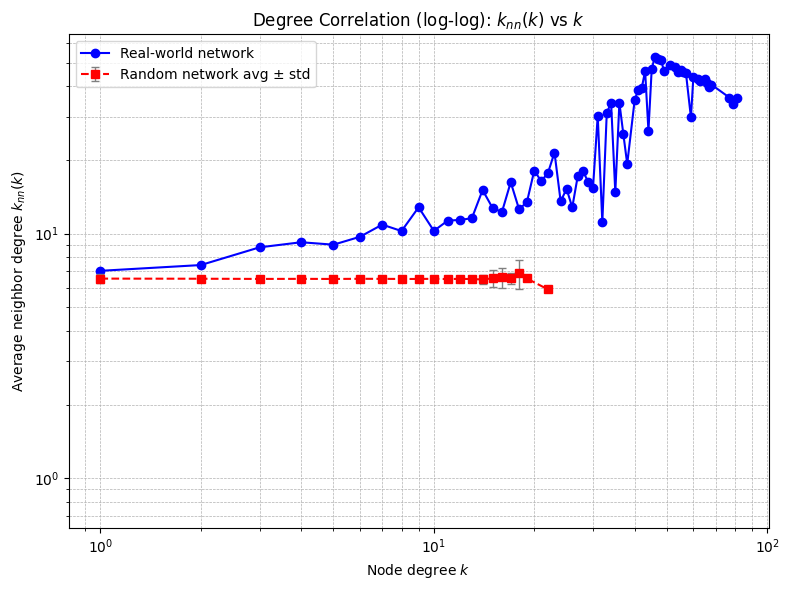

In [12]:
plot_degree_correlation_comparison(real_k, real_knn, rand_k, rand_knn, rand_std, "degree_correlation_comparison.png")